Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best SVM Parameters: {'C': 1, 'gamma': 1}
Best SVM CV Accuracy: 0.8
SVM Test Accuracy: 0.8809523809523809
SVM Classification Report:
               precision    recall  f1-score   support

         NSR       0.85      1.00      0.92        11
         CHF       1.00      0.67      0.80         9
          AF       0.87      0.91      0.89        22

    accuracy                           0.88        42
   macro avg       0.91      0.86      0.87        42
weighted avg       0.89      0.88      0.88        42



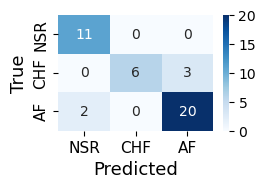

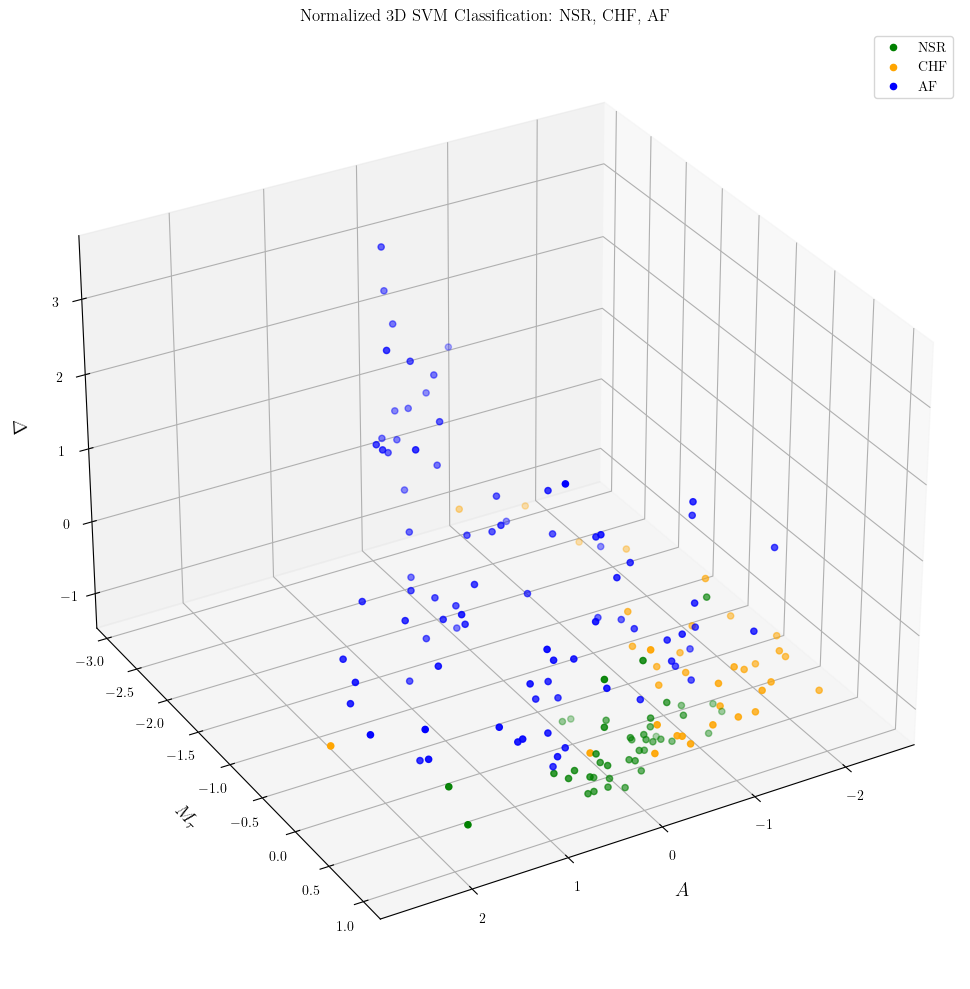

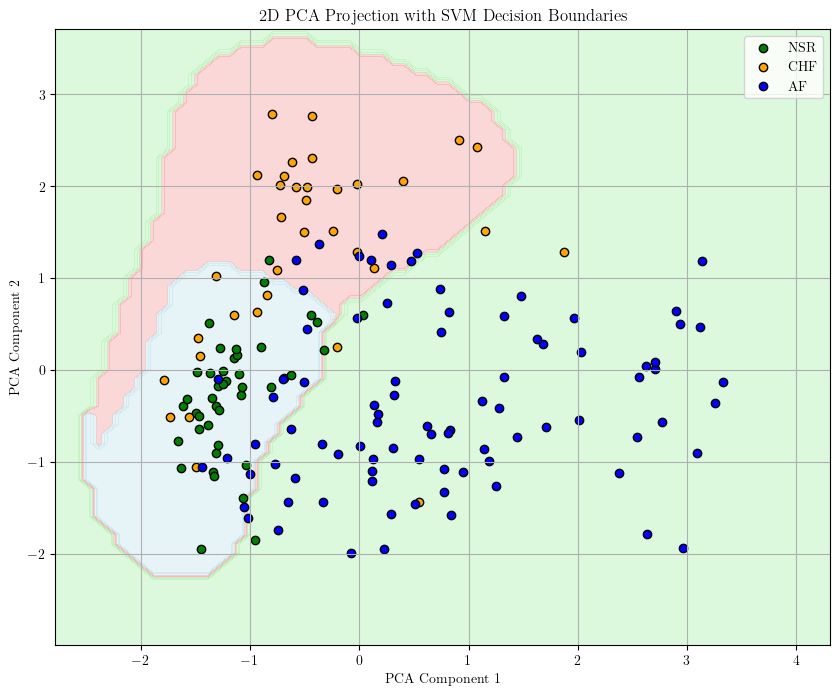

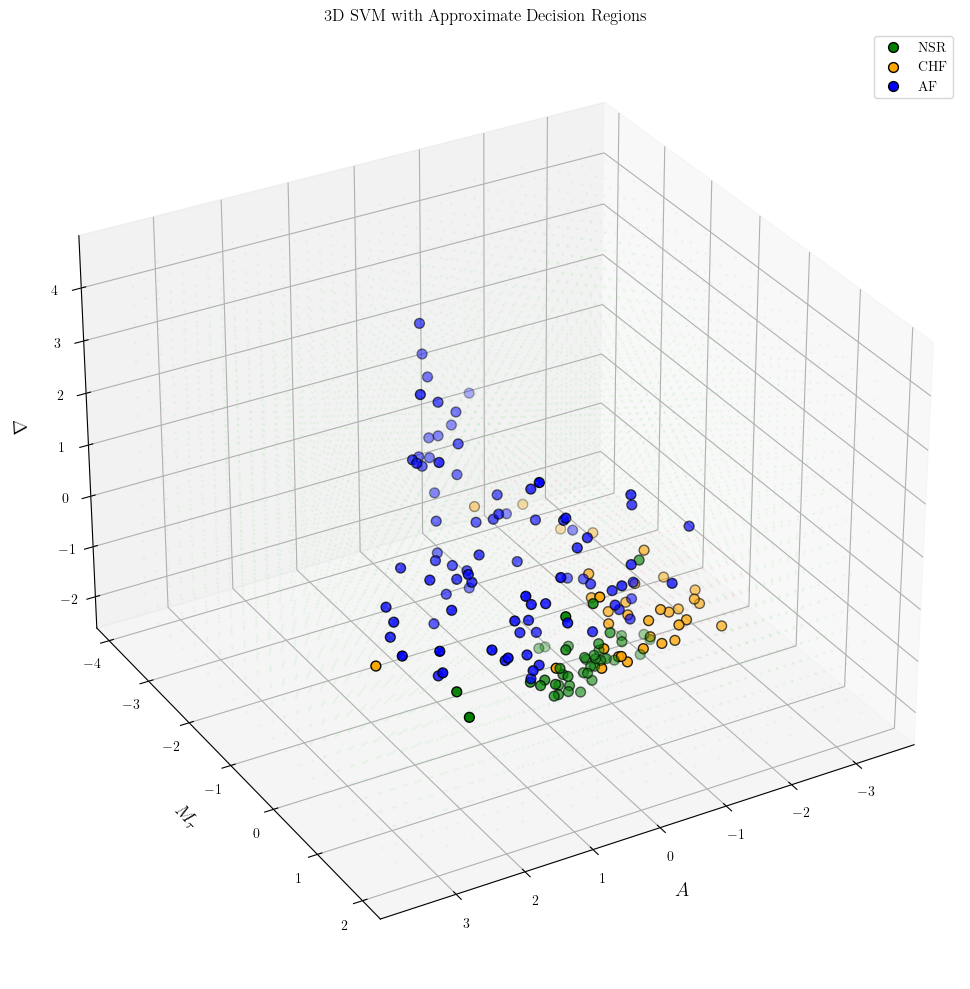

In [2]:
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib import rcParams  # this helps to change fonts (custom use)



# Enable LaTeX rendering for labels (optional)
plt.rcParams['text.usetex'] = False

# Step 1: Load data from files
def load_data(filepath):
    return np.loadtxt(filepath)

# Load burstiness
burst_nsr = load_data('burstiness_nsr.txt')
burst_chf = load_data('burstiness_chf.txt')
burst_af = load_data('burstiness_af.txt')

# Load memory
mem_nsr = load_data('memory_iet_nsr.txt')
mem_chf = load_data('memory_iet_chf.txt')
mem_af = load_data('memory_iet_af.txt')

# Load time scale
ts_nsr = load_data('smoothed_Dt_interval_nsr.txt')
ts_chf = load_data('smoothed_Dt_interval_chf.txt')
ts_af = load_data('smoothed_Dt_interval_af.txt')

#load delta peak
peak_nsr = load_data('original_Delta_peak_700_nsr.txt') #NSR
peak_chf = load_data('original_Delta_peak_700_chf.txt') #CHF
peak_af = load_data('original_Delta_peak_700_af.txt') #AF


# Step 2: Create dataset
data = []
labels = []

for b, m, t, p in zip(burst_nsr, mem_nsr, ts_nsr, peak_nsr):
    data.append([b, m, t, p])
    labels.append(0)
for b, m, t, p in zip(burst_chf, mem_chf, ts_chf, peak_chf):
    data.append([b, m, t, p])
    labels.append(1)
for b, m, t, p in zip(burst_af, mem_af, ts_af, peak_af):
    data.append([b, m, t, p])
    labels.append(2)

X = np.array(data)
y = np.array(labels)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3.5: Hyperparameter Tuning for SVM
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10]}
svm_model = svm.SVC(kernel='rbf', class_weight='balanced')
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)
print("Best SVM Parameters:", grid_search.best_params_)
print("Best SVM CV Accuracy:", grid_search.best_score_)

clf_svm = grid_search.best_estimator_

# Alternative: Train Random Forest
#rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
#rf_model.fit(X_train, y_train)
#y_pred_rf = rf_model.predict(X_test)
#print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))

# Step 4: Evaluate SVM
y_pred_svm = clf_svm.predict(X_test)
print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm, target_names=['NSR', 'CHF', 'AF']))

rcParams["font.family"] = "sans-serif"

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
max_val = np.max(cm)
plt.figure(figsize=(2.5, 1.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NSR', 'CHF', 'AF'], yticklabels=['NSR', 'CHF', 'AF'], cbar_kws={'ticks': np.arange(0, max_val + 1, 5)})
rcParams["font.family"] = "Arial"

# Increase fonts
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)

# Increase colorbar label font
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
#cbar.set_label("Count", fontsize=14)
#plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_matrix.pdf', bbox_inches='tight') 
plt.show()

plt.rcParams['text.usetex'] = True

# Step 5: Visualize 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
colors = ['green', 'orange', 'blue']
for label, color in zip([0, 1, 2], colors):
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1], X_train[mask, 2], c=color, label=f'{["NSR", "CHF", "AF"][label]}')
ax.set_xlabel(r'$A$', fontsize=14, labelpad=10)
ax.set_ylabel(r'$M_{\tau}$', fontsize=14, labelpad=10)
ax.set_zlabel(r'$\Delta$', fontsize=14, labelpad=10)
ax.legend()
plt.title('Normalized 3D SVM Classification: NSR, CHF, AF')
ax.view_init(elev=30, azim=60)
plt.tight_layout()
plt.show()

# NEW: 2D PCA Projection with Decision Boundaries
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Create a mesh grid for the 2D plot
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict on the grid
grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_original = pca.inverse_transform(grid_pca)
Z = clf_svm.predict(grid_original)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['lightblue', 'lightcoral', 'lightgreen'])
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
for label, color in zip([0, 1, 2], colors):
    mask = y_train == label
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], c=color, edgecolor='k', label=f'{["NSR", "CHF", "AF"][label]}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.title('2D PCA Projection with SVM Decision Boundaries')
plt.grid(True)
plt.show()

# NEW: 3D Scatter with Approximate Decision Regions
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a 3D mesh grid
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
z_min, z_max = X_train[:, 2].min() - 1, X_train[:, 2].max() + 1
xx, yy, zz = np.meshgrid(np.linspace(x_min, x_max, 20),
                         np.linspace(y_min, y_max, 20),
                         np.linspace(z_min, z_max, 20))

# Fix the 4th feature at its mean for visualization
mean_4th = np.mean(X_train[:, 3])

# Predict on the 3D grid (with 4th feature fixed)
grid_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel(), np.full(xx.ravel().shape, mean_4th)]
Z = clf_svm.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot regions
colors_regions = ['lightblue', 'lightcoral', 'lightgreen']
for class_label in [0, 1, 2]:
    mask = (Z == class_label)
    if np.any(mask):
        ax.scatter(xx[mask], yy[mask], zz[mask], c=colors_regions[class_label], alpha=0.1, s=1)

# Overlay data points
for label, color in zip([0, 1, 2], colors):
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1], X_train[mask, 2], c=color, s=50, edgecolor='k', label=f'{["NSR", "CHF", "AF"][label]}')

ax.set_xlabel(r'$A$', fontsize=14, labelpad=10)
ax.set_ylabel(r'$M_{\tau}$', fontsize=14, labelpad=10)
ax.set_zlabel(r'$\Delta$', fontsize=14, labelpad=10)
ax.legend()
plt.title('3D SVM with Approximate Decision Regions')
ax.view_init(elev=30, azim=60)
plt.tight_layout()
plt.savefig('3d_normalized.pdf', bbox_inches='tight')  
plt.show()
